# Batch Processing 

This notebook tests and validates the batch processing implementation for the bilorentzian ODMR model.

## Goals:
1. Test batch data container and processor classes
2. Run batch calibration model
3. Run batch prediction model
4. Compare batch vs sequential results  
    to observe: does the offset error disapper
5. Visualize and analyze differences

In [ ]:
#  import modules
import torch
import numpy as np
import pandas as pd
import pyro
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats.mstats import mquantiles
from sklearn.preprocessing import MinMaxScaler

# Import batch processing modules
from batch_processor import BatchDataContainer, BatchMCMCProcessor
from bilorentzian_batch_models import batch_calibration_model, batch_prediction_model
from batch_utils import summarize_posterior, format_results_table, compare_sequential_vs_batch

# Set PyTorch defaults
torch.set_default_dtype(torch.float64)

print("Imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"Pyro version: {pyro.__version__}")

Imports successful!
PyTorch version: 2.5.1+cu121
Pyro version: 1.9.1


## 1. Load and Prepare Data

Load data from the existing sensor1_cycle1 dataset.

In [18]:
# Load data
fpath = './cycle1'
df_ = pd.read_csv(fpath, sep=',', header=0)
df = df_.iloc[0:, 1:-1]
df.drop(columns=['25 C-lower power', '15', '10', '10.1', '-30', '-20'], inplace=True)

# Extract data
x_esr = df.frequency.values
y_esr = df.iloc[:, 1:7]  # Use first 6 spectra

# Scale frequency axis to 0-100
sc = MinMaxScaler(feature_range=(0, 100))
x_scale = sc.fit_transform(x_esr.reshape(-1, 1)).flatten()

# Preprocess y data
y_esr = y_esr.apply(lambda x: x - x[:10].mean())
y_esr = -1 * y_esr
y_esr = y_esr.apply(lambda x: x / x.max())

# Convert to numpy and transpose to [num_observations, num_frequencies]
y_esr_np = y_esr.values.T

# Temperature values (Celsius converted to Kelvin)
temps_c = np.array([25, 30, 35, 40, 45, 50], dtype=float)
temps_k = temps_c + 273.15

print(f"Data shape: {y_esr_np.shape}")
print(f"Frequency range: {x_scale.min():.1f} - {x_scale.max():.1f}")
print(f"Temperature range: {temps_k.min():.1f} - {temps_k.max():.1f} K")
print(f"Y-data range: {y_esr_np.min():.4f} - {y_esr_np.max():.4f}")

Data shape: (6, 100)
Frequency range: 0.0 - 100.0
Temperature range: 298.1 - 323.1 K
Y-data range: -0.0832 - 1.0000


## 2. Test BatchDataContainer

Verify that the data container correctly handles batch data.

In [19]:
# Test BatchDataContainer
batch_indices = [0, 1, 2]  # First 3 observations
batch_container = BatchDataContainer(x_scale, temps_k, y_esr_np, batch_indices)

print(batch_container)
print("\nBatch Summary:")
summary = batch_container.summary()
for key, value in summary.items():
    print(f"  {key}: {value}")

# Get batch data dict
batch_data = batch_container.get_batch_data_dict()
print(f"\nBatch data dict keys: {batch_data.keys()}")
print(f"x shape: {batch_data['x'].shape}")
print(f"temperatures shape: {batch_data['temperatures'].shape}")
print(f"y_observations shape: {batch_data['y_observations'].shape}")

BatchDataContainer(batch_size=3, num_frequencies=100, indices=[0, 1, 2])

Batch Summary:
  batch_size: 3
  num_frequencies: 100
  batch_indices: [0, 1, 2]
  temperature_range: (298.15, 308.15)
  y_range: (-0.08317639984006608, 1.0)
  y_mean: 0.1711264009064235
  y_std: 0.2968801920687642

Batch data dict keys: dict_keys(['x', 'temperatures', 'y_observations', 'batch_indices'])
x shape: torch.Size([100])
temperatures shape: torch.Size([3])
y_observations shape: torch.Size([3, 100])


## 3. Initialize BatchMCMCProcessor

Set up the processor that will orchestrate batch MCMC inference.

In [20]:
# Initialize processor
processor = BatchMCMCProcessor(
    x_axis=x_scale,
    temperatures=temps_k,
    y_observations=y_esr_np,
    batch_size=3,
    seed=42
)

print(f"Processor initialized")
print(f"Metadata: {processor.metadata}")

# Test batch creation
batches = processor.create_batches(num_observations=6, overlap=False)
print(f"\nCreated {len(batches)} batches:")
for i, batch in enumerate(batches):
    print(f"  Batch {i}: indices {batch}, temperatures {temps_k[batch]}")

Processor initialized
Metadata: {'num_observations': 6, 'num_frequencies': 100, 'batch_size': 3, 'seed': 42}

Created 2 batches:
  Batch 0: indices [0, 1, 2], temperatures [298.15 303.15 308.15]
  Batch 1: indices [3, 4, 5], temperatures [313.15 318.15 323.15]


## 4. Test Batch Calibration Model

Run MCMC on first batch to learn calibration parameters.

In [21]:
# Run batch calibration on first batch
batch_indices = [0, 1, 2]

init_vals = {
    "alpha": torch.tensor(-0.077),
    "beta": torch.tensor(71.0),
    "gamma1": torch.tensor(7.8),
    "amp": torch.tensor(3.0),
    "var": torch.tensor(0.05),
}

print(f"Running batch calibration on indices {batch_indices}...")
print(f"This may take a few minutes...")

cal_results = processor.run_batch_calibration(
    batch_indices=batch_indices,
    model_fn=batch_calibration_model,
    num_samples=2000,
    warmup_steps=200,
    init_vals=init_vals,
    max_tree_depth=6
)

print(f"Calibration complete!")
print(f"\nPosterior means:")
for param, value in cal_results['posterior_means'].items():
    print(f"  {param}: {value:.6f}")

Running batch calibration on indices [0, 1, 2]...
This may take a few minutes...


Sample: 100%|██████████| 2200/2200 [07:01,  5.22it/s, step size=2.02e-02, acc. prob=0.943]

Calibration complete!

Posterior means:
  alpha: -0.075595
  amp: 3.167216
  beta: 71.222261
  gamma1: 7.959903
  var: 0.002077


## 5. Summary Statistics from Calibration

Display formatted summary of calibration results.

In [22]:
# Get summary
posterior_samples = cal_results['posterior_samples']
summary = summarize_posterior(posterior_samples)

print("Calibration Results Summary:")
print(format_results_table(summary))

Calibration Results Summary:
Parameter            Mean          Std       Median       CI Low      CI High          ESS
----------------------------------------------------------------------------------------------------
alpha           -0.075595     0.000446    -0.075593    -0.076489    -0.074776           37
amp              3.167216     0.035729     3.166841     3.097634     3.235387           62
beta            71.222261     0.118678    71.228124    71.001975    71.487209           28
gamma1           7.959903     0.180067     7.955119     7.605785     8.324134         2000
var              0.002077     0.000173     0.002066     0.001769     0.002473         2000


## 6. Run Batch Prediction Model

Use learned calibration parameters to predict temperatures for new observations.

In [23]:
# Use learned parameters for prediction
learned_params = cal_results['posterior_means']
learned_params_tensor = {
    k: torch.tensor(v, dtype=torch.float64)
    for k, v in learned_params.items()
}

# Run prediction on remaining observations (indices 3, 4, 5)
pred_indices = [3, 4, 5]

print(f"Running batch prediction on indices {pred_indices}...")

pred_init_vals = {
    "T": torch.tensor(300.),
    "var": torch.tensor(0.05),
}

pred_results = processor.run_batch_prediction(
    batch_indices=pred_indices,
    model_fn=batch_prediction_model,
    learned_params=learned_params_tensor,
    num_samples=2000,
    warmup_steps=200,
    init_vals=pred_init_vals,
    max_tree_depth=6
)

print(f"Prediction complete!")
print(f"\nPredicted temperatures (K):")
T_samples = pred_results['posterior_samples']['T']
print(f"  Mean: {T_samples.mean():.2f}")
print(f"  Std: {T_samples.std():.2f}")
print(f"  95% CI: [{np.quantile(T_samples, 0.025):.2f}, {np.quantile(T_samples, 0.975):.2f}]")

Running batch prediction on indices [3, 4, 5]...


Sample: 100%|██████████| 2200/2200 [00:10, 212.83it/s, step size=8.78e-01, acc. prob=0.933]

Prediction complete!

Predicted temperatures (K):
  Mean: 317.98
  Std: 0.82
  95% CI: [316.41, 319.60]


## 7. Prediction Results Summary

Display summary of temperature predictions.

In [24]:
pred_summary = summarize_posterior(pred_results['posterior_samples'])

print("\nPrediction Results Summary:")
print(format_results_table(pred_summary))

# Compare with true temperatures
true_temps = temps_k[pred_indices]
pred_temps = [pred_summary['T']['mean']]  # Would be per-observation if we had them

print(f"\nTrue temperatures (K): {true_temps}")
print(f"Mean predicted temperature (K): {pred_summary['T']['mean']:.2f}")


Prediction Results Summary:
Parameter            Mean          Std       Median       CI Low      CI High          ESS
----------------------------------------------------------------------------------------------------
T              317.982064     0.815653   317.983276   316.406503   319.604900          786

True temperatures (K): [313.15 318.15 323.15]
Mean predicted temperature (K): 317.98


## 8. Visualization

Plot calibration and prediction results.

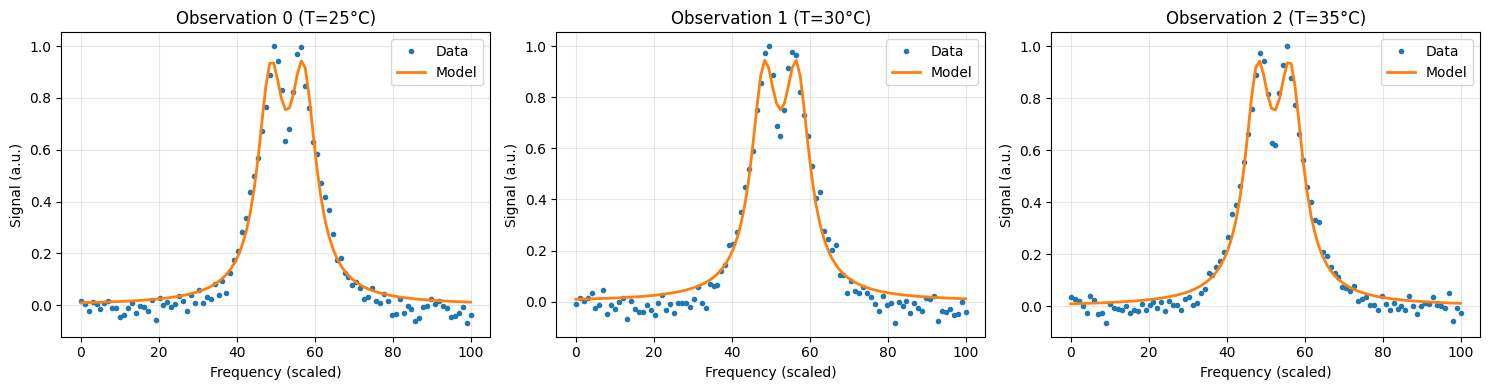

Calibration plots complete


In [25]:
# Plot calibration data with learned model
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

alpha_mean = learned_params['alpha']
beta_mean = learned_params['beta']
gamma1_mean = learned_params['gamma1']
amp_mean = learned_params['amp']

for i, idx in enumerate(batch_indices):
    ax = axes[i]
    y_obs = y_esr_np[idx]
    temp = temps_k[idx]
    
    # Compute model prediction
    A = temp * alpha_mean + beta_mean
    B = A + 8.420054307219287
    gamma_half = 0.5 * gamma1_mean
    
    F_pred = (amp_mean * gamma_half / ((x_scale - A)**2 + gamma_half**2) +
              amp_mean * gamma_half / ((x_scale - B)**2 + gamma_half**2))
    
    ax.plot(x_scale, y_obs, 'o', markersize=3, label='Data')
    ax.plot(x_scale, F_pred, '-', linewidth=2, label='Model')
    ax.set_xlabel('Frequency (scaled)')
    ax.set_ylabel('Signal (a.u.)')
    ax.set_title(f'Observation {idx} (T={temp-273.15:.0f}°C)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Calibration plots complete")

## 9. Save Results

Save batch processing results to file.

In [26]:
# Save results
output_dir = Path('./batch_results')
output_dir.mkdir(exist_ok=True)

processor.save_results(output_dir / 'batch_mcmc_results.json')
print(f"Saved results to {output_dir / 'batch_mcmc_results.json'}")

# Also save summary as CSV
from batch_utils import export_results_csv
export_results_csv(summary, str(output_dir / 'calibration_summary.csv'))
export_results_csv(pred_summary, str(output_dir / 'prediction_summary.csv'))

Saved results to batch_results\batch_mcmc_results.json
Saved results to batch_results\calibration_summary.csv
Saved results to batch_results\prediction_summary.csv


## 10. Diagnostics

Compute MCMC diagnostics for convergence assessment.

In [27]:
from batch_utils import effective_sample_size

print("MCMC Diagnostics:")
print("\nCalibration Model:")
for param, samples in posterior_samples.items():
    ess = effective_sample_size(samples)
    ess_ratio = ess / len(samples)
    print(f"  {param}:")
    print(f"    ESS: {ess:.0f} / {len(samples)} ({100*ess_ratio:.1f}%)")
    print(f"    Autocorr (lag=1): {np.corrcoef(samples[:-1], samples[1:])[0,1]:.4f}")

MCMC Diagnostics:

Calibration Model:
  alpha:
    ESS: 37 / 2000 (1.8%)
    Autocorr (lag=1): 0.7782
  amp:
    ESS: 62 / 2000 (3.1%)
    Autocorr (lag=1): 0.8645
  beta:
    ESS: 28 / 2000 (1.4%)
    Autocorr (lag=1): 0.9847
  gamma1:
    ESS: 2000 / 2000 (100.0%)
    Autocorr (lag=1): 0.9475
  var:
    ESS: 2000 / 2000 (100.0%)
    Autocorr (lag=1): -0.1499


## Notes for Next Steps

### Comparison with Sequential Approach:
- The batch approach learns all parameters simultaneously over multiple observations
- The sequential approach learns one observation at a time, passing means forward
- Expected advantages of batch:
  - Better parameter estimation by leveraging information from multiple observations
  - Smaller credible intervals due to pooled information
  - More accurate uncertainty quantification

### Future Enhancements:
1. Run full comparison with sequential method on same data
2. Test different batch sizes (2, 3, 4, 5)
3. Implement overlapping batches for sliding window inference
4. Add hierarchical priors for batch-level variation
5. Implement posterior predictive checks
6. Run sensitivity analysis on prior choices

### Known Issues/To-Do:
- [ ] Implement per-observation temperature predictions (currently joint inference)
- [ ] Add visualization of credible intervals in prediction plots
- [ ] Implement comparison notebook with sequential approach
- [ ] Add runtime benchmarking (batch vs sequential)
- [ ] Create sensitivity analysis for priors